# Fourier transform demo

This notebook demonstrates the solver-side projection and Fourier helpers:

- `solver.from_grid_vector(...)`
- `solver.to_grid_vector(...)`
- `solver.fourier(...)`
- `solver.double_fourier_transform(...)`

It uses the same analytic Gaussian-family cases as the unit tests, then shows arbitrary numerical profiles and a kernel double-transform example.

In [1]:
from __future__ import annotations

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import lax as lm

In [2]:
LEGENDRE_PLOT_GRID = jnp.linspace(0.01, 18.0, 400)
LAGUERRE_PLOT_GRID = jnp.linspace(0.0, 40.0, 800)
LEGENDRE_MOMENTA = jnp.linspace(0.0, 2.0, 200)
LAGUERRE_MOMENTA = jnp.linspace(0.0, 4.0, 600)


def legendre_solver(
    l: int,
    *,
    n: int = 24,
    scale: float = 18.0,
    grid=LEGENDRE_PLOT_GRID,
    momenta=LEGENDRE_MOMENTA,
) -> lm.Solver:
    return lm.compile(
        mesh=lm.MeshSpec("legendre", "x", n=n, scale=scale),
        channels=(lm.ChannelSpec(l=l, threshold=0.0, mass_factor=2.0),),
        solvers=(),
        grid=grid,
        momenta=momenta,
    )


def laguerre_solver(l: int, *, n: int = 100, scale: float = 1.0 / 2) -> lm.Solver:
    return lm.compile(
        mesh=lm.MeshSpec("laguerre", "x", n=n, scale=scale),
        channels=(lm.ChannelSpec(l=l, threshold=0.0, mass_factor=2.0),),
        solvers=(),
        grid=LAGUERRE_PLOT_GRID,
        momenta=LAGUERRE_MOMENTA,
    )


def relative_error(numerical: np.ndarray, analytic: np.ndarray) -> float:
    return float(np.linalg.norm(numerical - analytic) / np.linalg.norm(analytic))

## Analytic Gaussian-family Legendre examples

Gaussian l=0
  grid relative error    = 0.0013488916103167404
  momentum relative error= 7.66045694166148e-05
Gaussian x polynomial l=0
  grid relative error    = 0.006461741747238739
  momentum relative error= 0.0009215414050993526
Gaussian l=1
  grid relative error    = 0.0021696379970285416
  momentum relative error= 9.35147405288351e-06


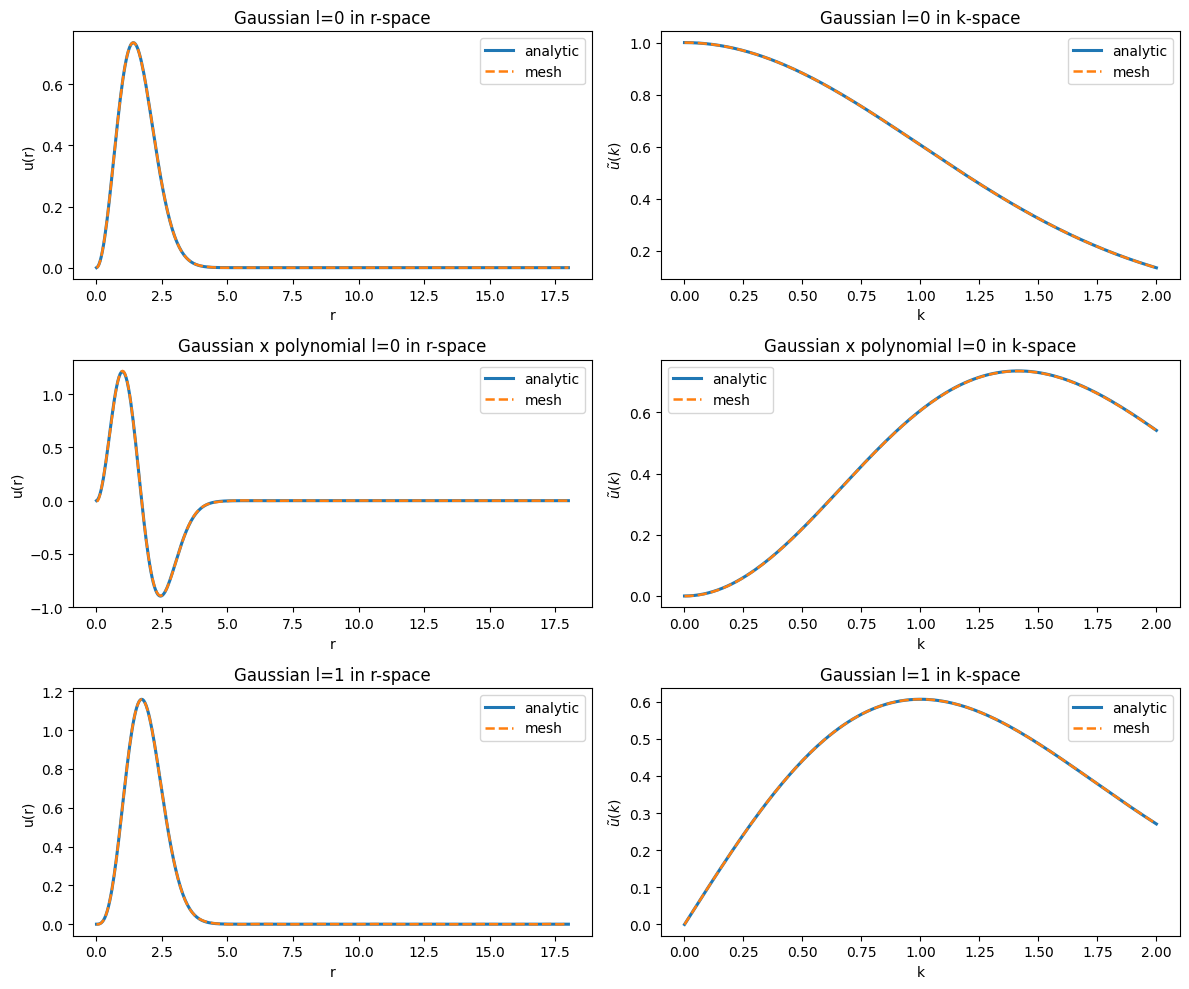

In [3]:
beta = 0.5
analytic_cases = [
    (
        "Gaussian l=0",
        0,
        lambda r: r**2 * np.exp(-beta * r**2),
        lambda k: np.exp(-(k**2) / (4.0 * beta)) / (2.0 * beta) ** 1.5,
    ),
    (
        "Gaussian x polynomial l=0",
        0,
        lambda r: r**2 * (3.0 / (2.0 * beta) - r**2) * np.exp(-beta * r**2),
        lambda k: ((k**2) / (4.0 * beta**2))
        * np.exp(-(k**2) / (4.0 * beta))
        / (2.0 * beta) ** 1.5,
    ),
    (
        "Gaussian l=1",
        1,
        lambda r: r**3 * np.exp(-beta * r**2),
        lambda k: k * np.exp(-(k**2) / (4.0 * beta)) / (2.0 * beta) ** 2.5,
    ),
]

fig, axes = plt.subplots(len(analytic_cases), 2, figsize=(12, 10))

for row, (name, l, profile, transform) in enumerate(analytic_cases):
    solver = legendre_solver(l)
    coeffs = solver.from_grid_vector(lambda r: jnp.asarray(profile(np.asarray(r))))
    grid_values = np.asarray(solver.to_grid_vector(coeffs))
    momentum_values = np.asarray(solver.fourier(coeffs))
    grid_r = np.asarray(solver.transforms.grid_r)
    momenta = np.asarray(solver.transforms.momenta)
    expected_grid = profile(grid_r)
    expected_k = transform(momenta)
    print(name)
    print("  grid relative error    =", relative_error(grid_values, expected_grid))
    print("  momentum relative error=", relative_error(momentum_values, expected_k))
    axes[row, 0].plot(grid_r, expected_grid, label="analytic", linewidth=2.2)
    axes[row, 0].plot(grid_r, grid_values, "--", label="mesh", linewidth=1.8)
    axes[row, 0].set_title(f"{name} in r-space")
    axes[row, 0].set_xlabel("r")
    axes[row, 0].set_ylabel("u(r)")
    axes[row, 0].legend()
    axes[row, 1].plot(momenta, expected_k, label="analytic", linewidth=2.2)
    axes[row, 1].plot(momenta, momentum_values, "--", label="mesh", linewidth=1.8)
    axes[row, 1].set_title(f"{name} in k-space")
    axes[row, 1].set_xlabel("k")
    axes[row, 1].set_ylabel(r"$\tilde u(k)$")
    axes[row, 1].legend()

fig.tight_layout()

## Arbitrary numerical Legendre examples

damped oscillation
  grid relative error = 4.0351490621330827e-14
double bump
  grid relative error = 0.005450708301416176


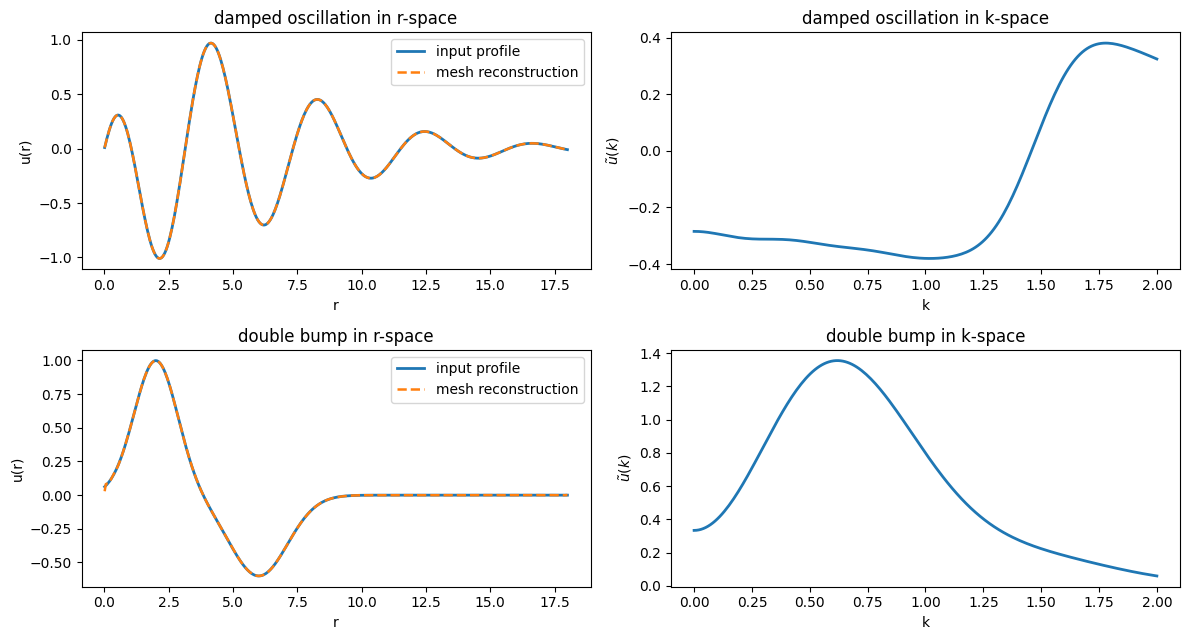

In [4]:
numerical_profiles = [
    ("damped oscillation", lambda r: r * np.exp(-0.35 * r) * np.cos(1.5 * r)),
    (
        "double bump",
        lambda r: np.exp(-0.7 * (r - 2.0) ** 2) - 0.6 * np.exp(-0.4 * (r - 6.0) ** 2),
    ),
]

numerical_solver = legendre_solver(0, n=40, scale=18.0)
fig, axes = plt.subplots(len(numerical_profiles), 2, figsize=(12, 6.5))
grid_r = np.asarray(numerical_solver.transforms.grid_r)
momenta = np.asarray(numerical_solver.transforms.momenta)

for row, (name, profile) in enumerate(numerical_profiles):
    coeffs = numerical_solver.from_grid_vector(
        lambda r: jnp.asarray(profile(np.asarray(r)))
    )
    reconstructed = np.asarray(numerical_solver.to_grid_vector(coeffs))
    transformed = np.asarray(numerical_solver.fourier(coeffs))
    expected = profile(grid_r)
    print(name)
    print("  grid relative error =", relative_error(reconstructed, expected))
    axes[row, 0].plot(grid_r, expected, label="input profile", linewidth=2.0)
    axes[row, 0].plot(
        grid_r, reconstructed, "--", label="mesh reconstruction", linewidth=1.8
    )
    axes[row, 0].set_title(f"{name} in r-space")
    axes[row, 0].set_xlabel("r")
    axes[row, 0].set_ylabel("u(r)")
    axes[row, 0].legend()
    axes[row, 1].plot(momenta, transformed, linewidth=2.0)
    axes[row, 1].set_title(f"{name} in k-space")
    axes[row, 1].set_xlabel("k")
    axes[row, 1].set_ylabel(r"$\tilde u(k)$")

fig.tight_layout()

## Kernel double Fourier-Bessel example

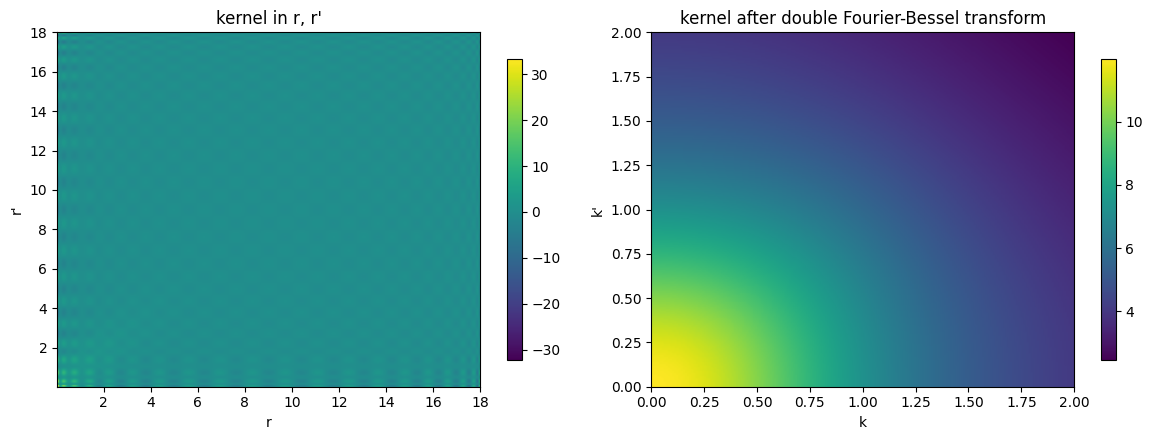

In [5]:
kernel_solver = legendre_solver(0, n=40, scale=18.0)

assert kernel_solver.to_grid_matrix is not None
assert kernel_solver.double_fourier_transform is not None


def gaussian_nonlocal_kernel(r1: jnp.ndarray, r2: jnp.ndarray) -> jnp.ndarray:
    return jnp.exp(-0.4 * (r1 - r2) ** 2) * jnp.exp(-0.05 * (r1**2 + r2**2))


ri, rj = jnp.meshgrid(kernel_solver.mesh.radii, kernel_solver.mesh.radii, indexing="ij")
mesh_kernel = gaussian_nonlocal_kernel(ri, rj)
grid_kernel = np.asarray(kernel_solver.to_grid_matrix(mesh_kernel))
momentum_kernel = np.asarray(kernel_solver.double_fourier_transform(mesh_kernel))
grid_r = np.asarray(kernel_solver.transforms.grid_r)
momenta = np.asarray(kernel_solver.transforms.momenta)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
image_r = axes[0].imshow(
    grid_kernel,
    origin="lower",
    aspect="auto",
    extent=[grid_r[0], grid_r[-1], grid_r[0], grid_r[-1]],
)
axes[0].set_title("kernel in r, r'")
axes[0].set_xlabel("r")
axes[0].set_ylabel("r'")
fig.colorbar(image_r, ax=axes[0], shrink=0.85)

image_k = axes[1].imshow(
    momentum_kernel,
    origin="lower",
    aspect="auto",
    extent=[momenta[0], momenta[-1], momenta[0], momenta[-1]],
)
axes[1].set_title("kernel after double Fourier-Bessel transform")
axes[1].set_xlabel("k")
axes[1].set_ylabel("k'")
fig.colorbar(image_k, ax=axes[1], shrink=0.85)
fig.tight_layout()

## Hydrogen Laguerre example

In [ ]:
def hydrogen_solver(l: int) -> lm.Solver:
    return lm.compile(
        mesh=lm.MeshSpec("laguerre", "x", n=30, scale=2.0),
        channels=(lm.ChannelSpec(l=l, threshold=0.0, mass_factor=0.5),),
        operators=("T", "1/r"),
        solvers=("spectrum", "wavefunction"),
        grid=LAGUERRE_PLOT_GRID,
        momenta=LAGUERRE_MOMENTA,
    )


def hydrogen_potential(solver: lm.Solver) -> lm.Interaction:
    # Build the Coulomb -1/r term as an Interaction (spectrum accepts only Interactions).
    assert solver.local_potential is not None
    return solver.local_potential(lambda r: -1.0 / r)


solver = hydrogen_solver(0)
spectrum = solver.spectrum(hydrogen_potential(solver))
coeffs_1s = spectrum.eigenvectors[:, 0]
u_r = np.asarray(solver.to_grid_vector(coeffs_1s))
u_k = np.asarray(solver.fourier(coeffs_1s))
grid_r = np.asarray(solver.transforms.grid_r)
momenta = np.asarray(solver.transforms.momenta)
analytic_u_k = np.sqrt(2.0 / np.pi) * 2.0 / (1.0 + momenta**2)
norm_r = np.trapezoid(np.abs(u_r) ** 2, grid_r)
norm_k = np.trapezoid(np.abs(u_k) ** 2, momenta)
analytic_norm_k = np.trapezoid(np.abs(analytic_u_k) ** 2, momenta)
print(f"Hydrogen 1s r-space norm (dr) ≈ {norm_r:.8f}")
print(f"Hydrogen 1s k-space amplitude norm (dk) ≈ {norm_k:.8f}")
print(f"Analytic 1s k-space amplitude norm on this grid ≈ {analytic_norm_k:.8f}")
print("The current solver.fourier(...) convention computes the partial-wave amplitude")
print("sqrt(2/pi) ∫ j_l(k r) u_l(r) dr, so its plain-dk norm is not expected")
print("to equal the r-space dr norm.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(grid_r, u_r, linewidth=2.0)
axes[0].set_title("Hydrogen 1s in r-space")
axes[0].set_xlabel("r")
axes[0].set_ylabel("u(r)")
axes[1].plot(momenta, u_k, linewidth=2.0)
axes[1].set_title("Hydrogen 1s in k-space")
axes[1].set_xlabel("k")
axes[1].set_ylabel(r"$\tilde u(k)$")
fig.tight_layout()